研究问题： 有淋巴结转移和无淋巴结转移的乳腺癌患者，其临床病理特征是否存在差异？
需要分析的变量：
     variable        中文   变量类型
0         Age        年龄   连续变量
1  Tumor_Size      肿瘤大小   连续变量
2        Ki67  Ki67表达水平   连续变量
3          ER      ER状态  二分类变量
4          PR      PR状态  二分类变量
5        HER2    HER状态   二分类变量
读取breast_cancer_clinical3.csv成功
Age:              Age
count  20.000000
mean   51.950000
std     8.666177
min    36.000000
25%    46.500000
50%    51.500000
75%    58.250000
max    67.000000
Tumor_Size:        Tumor_Size
count    20.00000
mean      3.19500
std       1.02108
min       1.50000
25%       2.45000
50%       3.10000
75%       3.85000
max       5.10000
Ki67: count    20.000000
mean     41.250000
std      31.450671
min      10.000000
25%      15.000000
50%      30.000000
75%      70.000000
max      95.000000
Name: Ki67, dtype: float64

对连续变量进行正态性检验：
Age的p值: 0.9788032525063932
Tumor_Size的p值: 0.9162922826518878
Ki67的p值: 0.002156689932776424
结果分析如下：
Age和Tumor_Size的p值均大于0.05，因此没有理由认为Age和Tumor_Size不符合方差齐性。
Ki67的p值小于0.05，

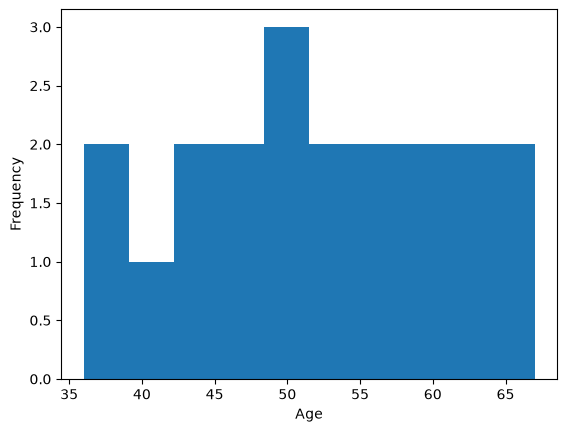

Age的Q-Q图:


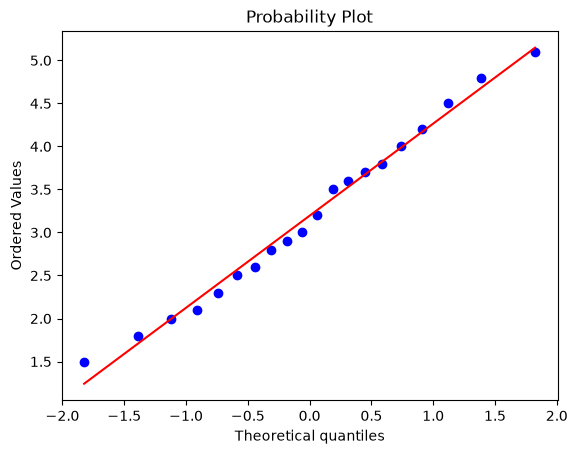

Tumor_Size的直方图：


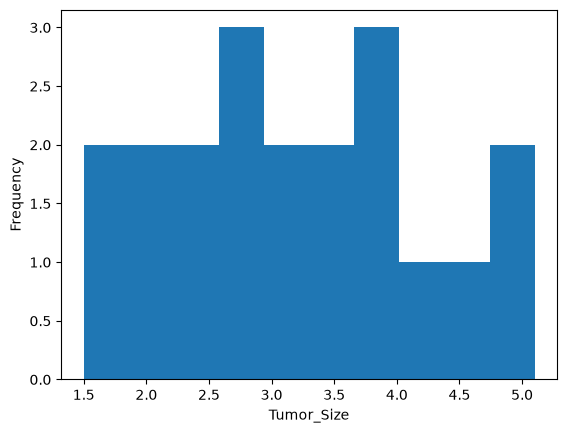

Tumor_Size的Q-Q图：


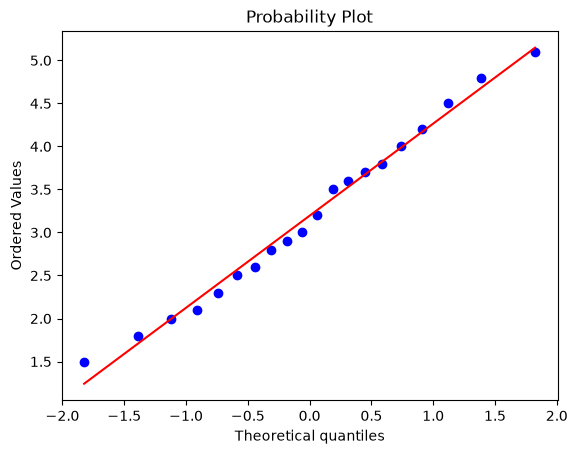

----------
Age和Tumor_Size的t检验:
Age的t值： -3.7742011369486237
Age的p值： 0.0017755616146161615
Tumor_Size的t值： -4.149738068893663
Tumor_Size的p值： 0.0007047471803138009
因为Age的p值<0.05,因此两组的年龄差异存在统计学意义。
因为Tumor_Size的p值<0.05，因此两组的Tumor_Size差异存在统计学意义。
---------
Ki67的Mann_Whitney_U检验：
Ki67的u值： 38.5
Ki67的p值： 0.42151799737413176
因为Ki67的p值>0.05,因此两组的Ki67水平未存在统计学差异。
-----------
连续变量统计表:
     Variable  Shapiro P Distribution Mean±SD/Median(Q1,Q3) Analysis  P value
0         Age      0.979       Normal            51.95±8.67   t-test   0.0010
1  Tumor_Size      0.916       Normal             3.20±1.02   t-test   0.0007
2        Ki67      0.002   Non-Normal             30(15,70)   u-test   0.4000
------------
分类变量的chi square检验
Lymph_Node  0  1
ER              
0           1  6
1           8  5
ERvsLN的p值: 0.11997996734471256
ERvsLN的expected: [[3.15 3.85]
 [5.85 7.15]]
Lymph_Node  0  1
PR              
0           2  9
1           7  2
PRvsLN的p值: 0.02686447196134021
PRvsLN的expected: [[4.95 6.05]
 [4.05 4.95]]

In [24]:
print('研究问题：','有淋巴结转移和无淋巴结转移的乳腺癌患者，其临床病理特征是否存在差异？')
print('需要分析的变量：')
import pandas as pd
table1=pd.DataFrame({
    'variable':['Age','Tumor_Size','Ki67','ER','PR','HER2'],
    '中文':['年龄','肿瘤大小','Ki67表达水平','ER状态','PR状态','HER状态 '],
    '变量类型':['连续变量','连续变量','连续变量','二分类变量','二分类变量','二分类变量']
})
print(table1)
import pandas as pd 
df=pd.read_csv('breast_cancer_clinical3.csv')
print('读取breast_cancer_clinical3.csv成功')
print('Age:',df[['Age']].describe())
print('Tumor_Size:',df[['Tumor_Size']].describe())
print('Ki67:',df['Ki67'].describe())
print()
print('对连续变量进行正态性检验：')
import scipy
from scipy.stats import shapiro
stat,p=shapiro(df['Age'])
print('Age的p值:',p)
stat,p=shapiro(df['Tumor_Size'])
print('Tumor_Size的p值:',p)
stat,p=shapiro(df['Ki67'])
print('Ki67的p值:',p)
print('结果分析如下：')
print('Age和Tumor_Size的p值均大于0.05，因此没有理由认为Age和Tumor_Size不符合方差齐性。')
print('Ki67的p值小于0.05，因此Ki67不符合方差齐性')
print('Age的直方图：')
import matplotlib.pyplot as plt
plt.hist(df['Age'],bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
print('Age的Q-Q图:')
import scipy.stats as stats
import matplotlib.pyplot as plt
stats.probplot(df['Tumor_Size'],dist='norm',plot=plt)
plt.show()
print('Tumor_Size的直方图：')
plt.hist(df['Tumor_Size'],bins=10)
plt.xlabel('Tumor_Size')
plt.ylabel('Frequency')
plt.show()
print('Tumor_Size的Q-Q图：')
stats.probplot(df['Tumor_Size'],dist='norm',plot=plt)
plt.show()
print('----------')
print('Age和Tumor_Size的t检验:')
LN0=df[df['Lymph_Node']==0]
LN1=df[df['Lymph_Node']==1]
from scipy.stats import ttest_ind
t,p=ttest_ind(LN0['Age'],LN1['Age'],equal_var=False)
print('Age的t值：',t)
print('Age的p值：',p)
t,p=ttest_ind(LN0['Tumor_Size'],LN1['Tumor_Size'],equal_var=False)
print('Tumor_Size的t值：',t)
print('Tumor_Size的p值：',p)
print('因为Age的p值<0.05,因此两组的年龄差异存在统计学意义。')
print('因为Tumor_Size的p值<0.05，因此两组的Tumor_Size差异存在统计学意义。')
print('---------')
print('Ki67的Mann_Whitney_U检验：')
from scipy.stats import mannwhitneyu
u,p=mannwhitneyu(LN0['Ki67'],LN1['Ki67'],alternative='two-sided')
print('Ki67的u值：',u)
print('Ki67的p值：',p)
print('因为Ki67的p值>0.05,因此两组的Ki67水平未存在统计学差异。')
print('-----------')
table5=pd.DataFrame({
    'Variable':['Age','Tumor_Size','Ki67'],
    'Shapiro P':[0.979,0.916,0.002],
    'Distribution':['Normal','Normal','Non-Normal'],
    'Mean±SD/Median(Q1,Q3)':['51.95±8.67','3.20±1.02','30(15,70)'],
    'Analysis':['t-test','t-test','u-test'],
    'P value':[0.001,0.0007,0.4]
})
print('连续变量统计表:')
print(table5)
table5.to_excel('Table 1. Characteristics of Breast Cancer Patients.xlsx')
print('------------')
print('分类变量的chi square检验')
from scipy.stats import chi2_contingency
table2=pd.crosstab(df['ER'],df['Lymph_Node'])
print(table2)
chi2,p,dof,expected=chi2_contingency(table2)
print('ERvsLN的p值:',p)
print('ERvsLN的expected:',expected)
table3=pd.crosstab(df['PR'],df['Lymph_Node'])
print(table3)
chi2,p,dof,expected=chi2_contingency(table3)
print('PRvsLN的p值:',p)
print('PRvsLN的expected:',expected)
table4=pd.crosstab(df['HER2'],df['Lymph_Node'])
print(table4)
chi2,p,dof,expected=chi2_contingency(table4)
print('HER2vsLN的p值：',p)
print('HER2vsLN的expected:',expected)
print('统计结果如下：')
print('ER和HER2的表达状态与淋巴结转移未发现显著关联。')
print('PR的表达状态与淋巴结转移存在统计学关联。')
print('(说明：1.expected的值不满足>5超过80%。2.样本量太少 所以最好进行fisher检测)')
print('----------')
print('分类变量的fisher检测：')
from scipy.stats import fisher_exact
oddsratio,p=fisher_exact(table2)
print('ERvsLN的OR值：',oddsratio)
print('ERvsLN的p值：',p)
oddsratio,p=fisher_exact(table3)
print('PRvsLN的OR值：',oddsratio)
print('PRvsLN的p值：',p)
oddsratio,p=fisher_exact(table4)
print('HER2vsLN的OR值：',oddsratio)
print('HER2vsLN的p值：',p)
print('ER和HER2的表达状态与淋巴结转移未发现显著关联。')
print('PR的表达状态与淋巴结转移存在统计学关联。')
print('----------')
table6=pd.DataFrame({
    'Variable':['ER','PR','HER2'],
    'Expected是否合适':['否','否','否'],
    '最终方法':['Fisher','Fisher','Fisher'],
    'P value':[0.07,0.02,0.07]
})
print('分类变量统计表：')
print(table6)
table6.to_excel('Table 2. Characteristics of Breast Cancer Patients.xlsx')

    









